Saving flood_dataset.csv to flood_dataset (2).csv
✅ Dataset Loaded: (2540, 18)
Columns: ['disno', 'iso3', 'country', 'year', 'month', 'day', 'latitude', 'longitude', 'disaster subtype', 'river basin', 'deaths', 'affected', 'damage_usd', 'population', 'clim_annual_precipitation', 'clim_precip_wettest_month', 'hydro_avg_discharge_m3s', 'severe']
✅ Preprocessing complete. Categorical columns encoded: ['country', 'iso3', 'disaster_subtype', 'river_basin']
✅ Features and target defined.
Feature columns: ['iso3', 'country', 'year', 'month', 'day', 'latitude', 'longitude', 'disaster_subtype', 'river_basin', 'deaths', 'affected', 'damage_usd', 'population', 'clim_annual_precipitation', 'clim_precip_wettest_month', 'hydro_avg_discharge_m3s']
✅ Model trained.
📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       367
           1       1.00      0.99      1.00       141

    accuracy                           1.00       5

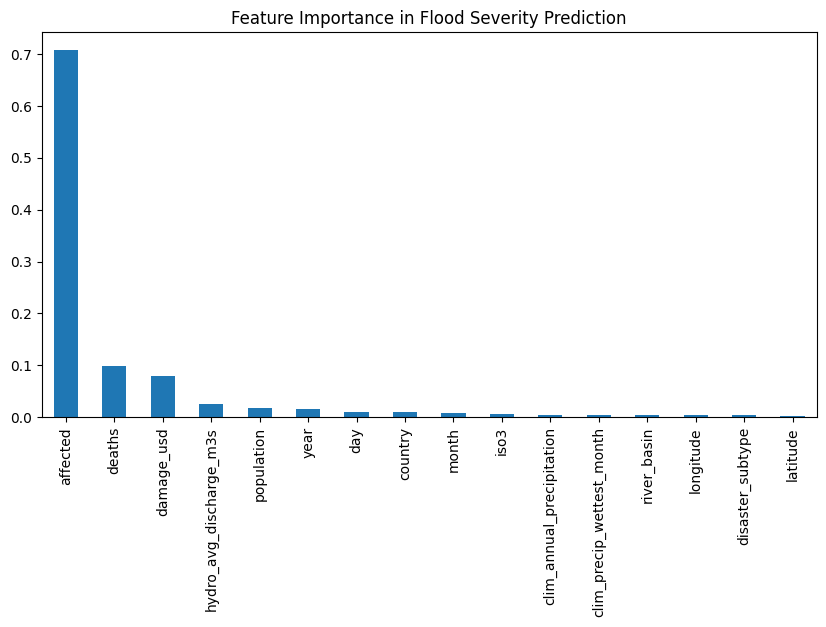

In [ ]:

!pip install pandas scikit-learn plotly geopandas matplotlib


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


from google.colab import files
uploaded = files.upload()


df = pd.read_csv("flood_dataset.csv")
print("✅ Dataset Loaded:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


df = df.fillna(0)

possible_categorical = ["country", "iso3", "disaster_subtype", "river_basin"]
categorical_cols = [col for col in possible_categorical if col in df.columns]

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("✅ Preprocessing complete. Categorical columns encoded:", categorical_cols)


if 'severe' not in df.columns:
    raise ValueError("❌ Target column 'severe' not found in dataset!")


drop_cols = ['disno'] if 'disno' in df.columns else []

X = df.drop(columns=drop_cols + ['severe'])  # features
y = df['severe']                               # target

print("✅ Features and target defined.")
print("Feature columns:", X.columns.tolist())

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Train Random Forest model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
print("✅ Model trained.")

# Step 8: Evaluate
y_pred = model.predict(X_test)
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))
print("🔍 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Step 9: Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,5))
feat_imp.plot(kind="bar")
plt.title("Feature Importance in Flood Severity Prediction")
plt.show()

# Step 10: Visualize predictions by country (if 'country' exists)
if 'country' in df.columns:
    df['predicted_severe'] = model.predict(X)

    country_severity = df.groupby("country")["predicted_severe"].mean().reset_index()

    fig = px.choropleth(
        country_severity,
        locations="country",
        locationmode="ISO-3",
        color="predicted_severe",
        hover_name="country",
        color_continuous_scale="Reds",
        title="🌍 Predicted Flood Severity by Country"
    )
    fig.show()
else:
    print("⚠️ Column 'country' not found. Skipping country map visualization.")
